Titanic Dataset - Exploratory Data Analysis (EDA)

Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on the Titanic dataset from Kaggle. The analysis includes data cleaning, handling missing values, visualizing important patterns, and identifying factors that influenced passenger survival.

 Import Required Libraries

The following libraries are imported to perform data manipulation, numerical computations, and data visualization.

- Pandas – Data manipulation and analysis.
- NumPy– Numerical operations.
- Matplotlib – Basic data visualization.
- Seaborn – Statistical data visualization with attractive plots.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
import numpy as np
import seaborn as sns

 Load the Titanic Dataset

The dataset is loaded into a Pandas DataFrame using the `read_csv()` function. This DataFrame will be used throughout the analysis.

In [12]:
df = pd.read_csv(r"C:\Users\Rohith Lingam\Downloads\titanic\train.csv")

 Dataset Information

This section provides an overview of the dataset, including:

- Number of rows and columns
- Column names
- Data types
- Missing values
- Summary statistics

In [17]:
df.head()
df.tail()
df.shape
df.columns
df.info()
df.describe()
df.describe(include='object')

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


C:\Users\Rohith Lingam\AppData\Local\Temp\ipykernel_15808\648627403.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


 Missing Value Analysis

Missing values can affect the quality of analysis and machine learning models. This step identifies the number of missing values present in each column.

In [18]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

 Data Cleaning

Data cleaning improves the quality of the dataset by handling missing values and removing unnecessary information.

Cleaning steps performed:

- Missing values in **Age** are replaced with the median.
- Missing values in **Embarked** are replaced with the mode.
- The **Cabin** column is removed because it contains a large number of missing values.
- Duplicate records are checked and removed if necessary.

In [20]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [21]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [22]:
df = df.drop("Cabin", axis=1)

 Verify Data Cleaning

After cleaning the dataset, the missing values are checked again to ensure that the data is ready for analysis.

In [23]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [ ]:
 Survival by Gender

A bar chart is created to compare the survival count of male and female passengers.

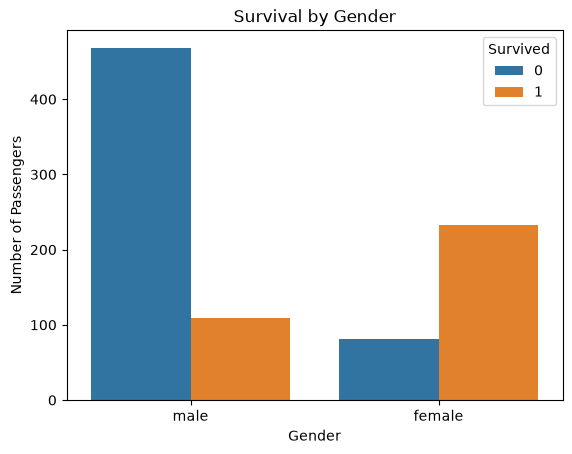

In [26]:
sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

Insight

Female passengers had a significantly higher survival rate compared to male passengers. This indicates that women were given higher priority during the rescue operation.

Survival by Passenger Class

This analysis compares survival among passengers traveling in different classes.

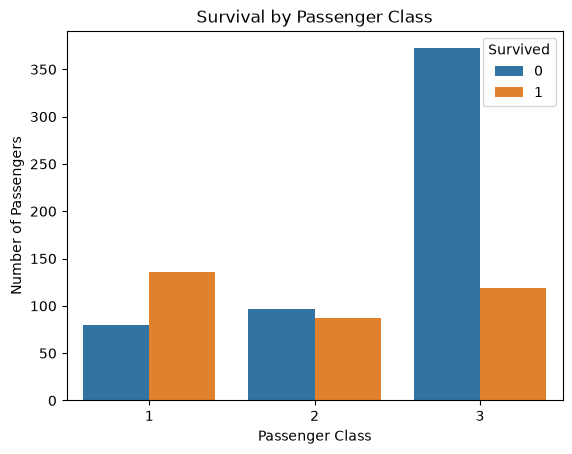

In [27]:
sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

Insight

Passengers traveling in First Class had the highest survival rate, while passengers in Third Class had the lowest survival rate. Passenger class had a strong influence on survival.

Survival by Age Group

Passengers are divided into different age groups to analyze survival patterns across ages.

In [28]:
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

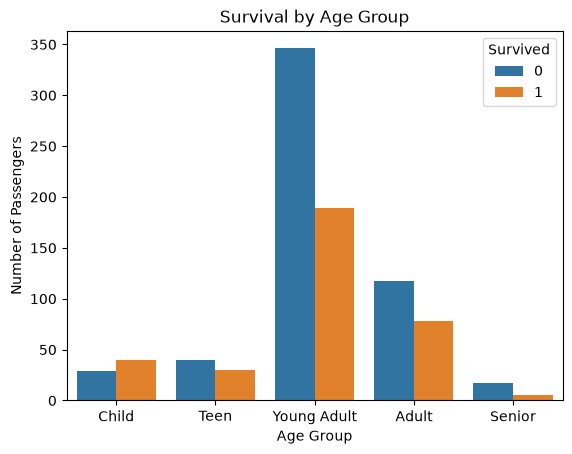

In [29]:
sns.countplot(x="AgeGroup", hue="Survived", data=df)

plt.title("Survival by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Passengers")

plt.show()

Insight

Children generally had better survival chances than adults and senior passengers, suggesting that age influenced rescue priorities.

Bar Chart: Survival by Gender

This visualization compares the number of passengers who survived and did not survive based on their gender. The chart helps identify whether gender had an influence on survival during the Titanic disaster.



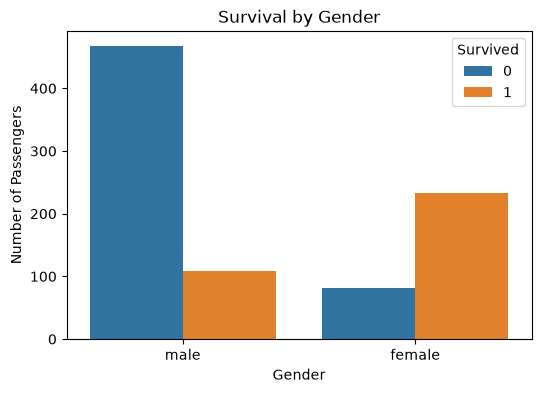

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

Insights
Female passengers had a much higher survival rate than male passengers. This suggests that women were given priority during the evacuation.

Bar Chart: Survival by Passenger Class

This visualization compares the survival status of passengers across the three passenger classes (First, Second, and Third Class). It helps determine whether ticket class influenced the likelihood of survival.


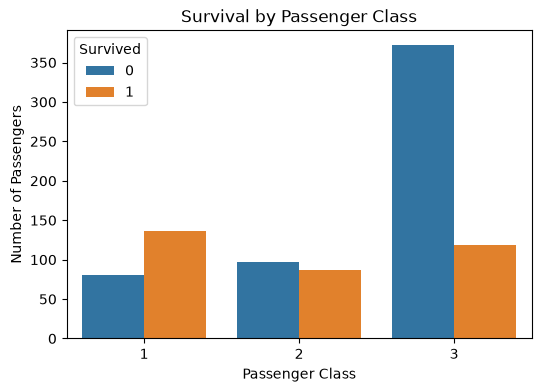

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

Insights
First-class passengers had the highest survival rate, while third-class passengers had the lowest. Passenger class significantly influenced survival chances.

Passenger Age Distribution

A histogram is plotted to understand how passengers are distributed across different age groups.

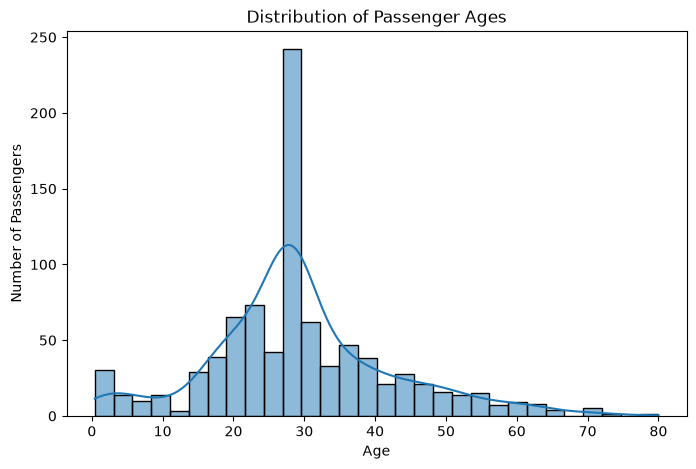

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

Insight

Most passengers were between 20 and 40 years old. The distribution indicates that young adults formed the largest group of passengers.